Time-based percentages (3-minute intervals starting from 0):
Time 0.0 min: Anti-parallel: 12.9%, Orthogonal: 23.3%, Parallel: 3.8%, Random: 60.0%
Time 3.0 min: Anti-parallel: 9.9%, Orthogonal: 20.7%, Parallel: 5.9%, Random: 63.5%
Time 6.0 min: Anti-parallel: 7.6%, Orthogonal: 13.6%, Parallel: 10.6%, Random: 68.2%
Time 9.0 min: Anti-parallel: 13.7%, Orthogonal: 22.1%, Parallel: 6.3%, Random: 57.9%
Time 12.0 min: Anti-parallel: 12.6%, Orthogonal: 21.3%, Parallel: 7.1%, Random: 59.0%
Time 15.0 min: Anti-parallel: 10.1%, Orthogonal: 16.1%, Parallel: 14.3%, Random: 59.5%
Time 18.0 min: Anti-parallel: 7.6%, Orthogonal: 22.2%, Parallel: 17.7%, Random: 52.5%
Time 21.0 min: Anti-parallel: 12.8%, Orthogonal: 18.8%, Parallel: 7.4%, Random: 61.1%
Time 24.0 min: Anti-parallel: 19.7%, Orthogonal: 13.8%, Parallel: 9.2%, Random: 57.2%
Time 27.0 min: Anti-parallel: 0.0%, Orthogonal: 4.3%, Parallel: 46.0%, Random: 49.6%
Time 30.0 min: Anti-parallel: 6.2%, Orthogonal: 7.0%, Parallel: 14.8%, Random: 71.9%

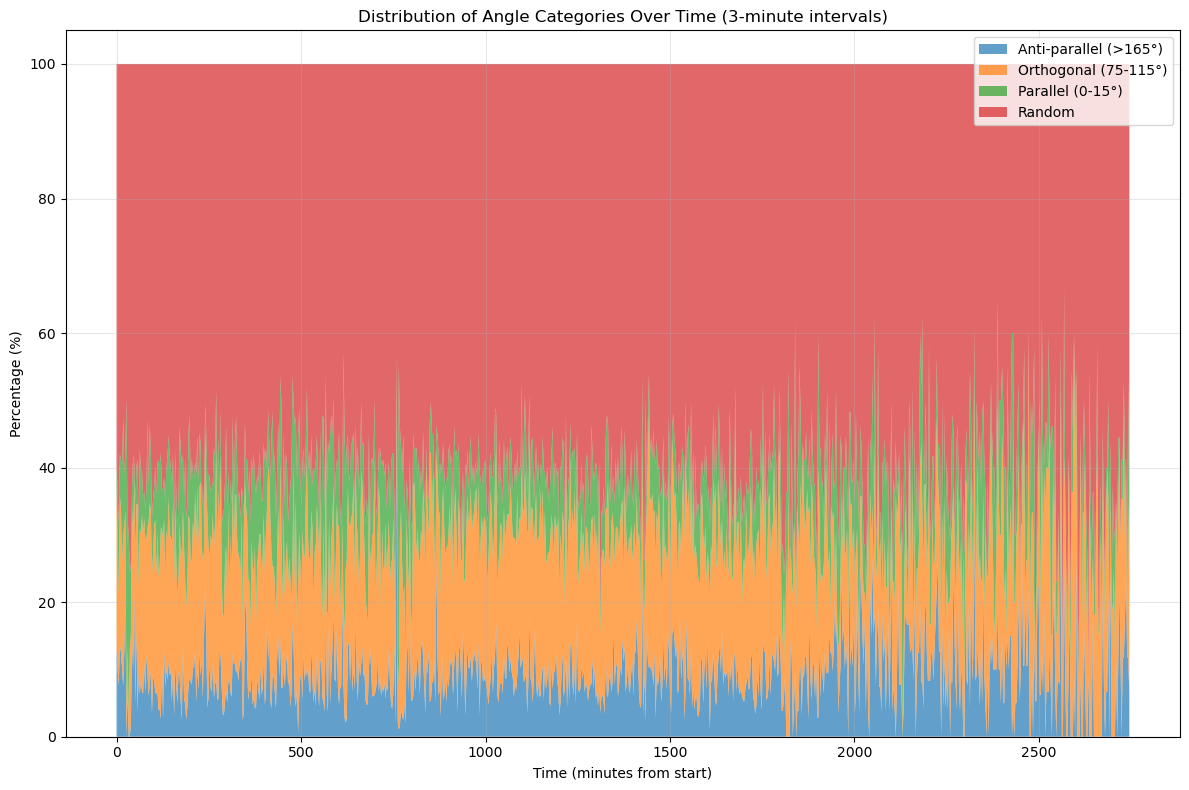

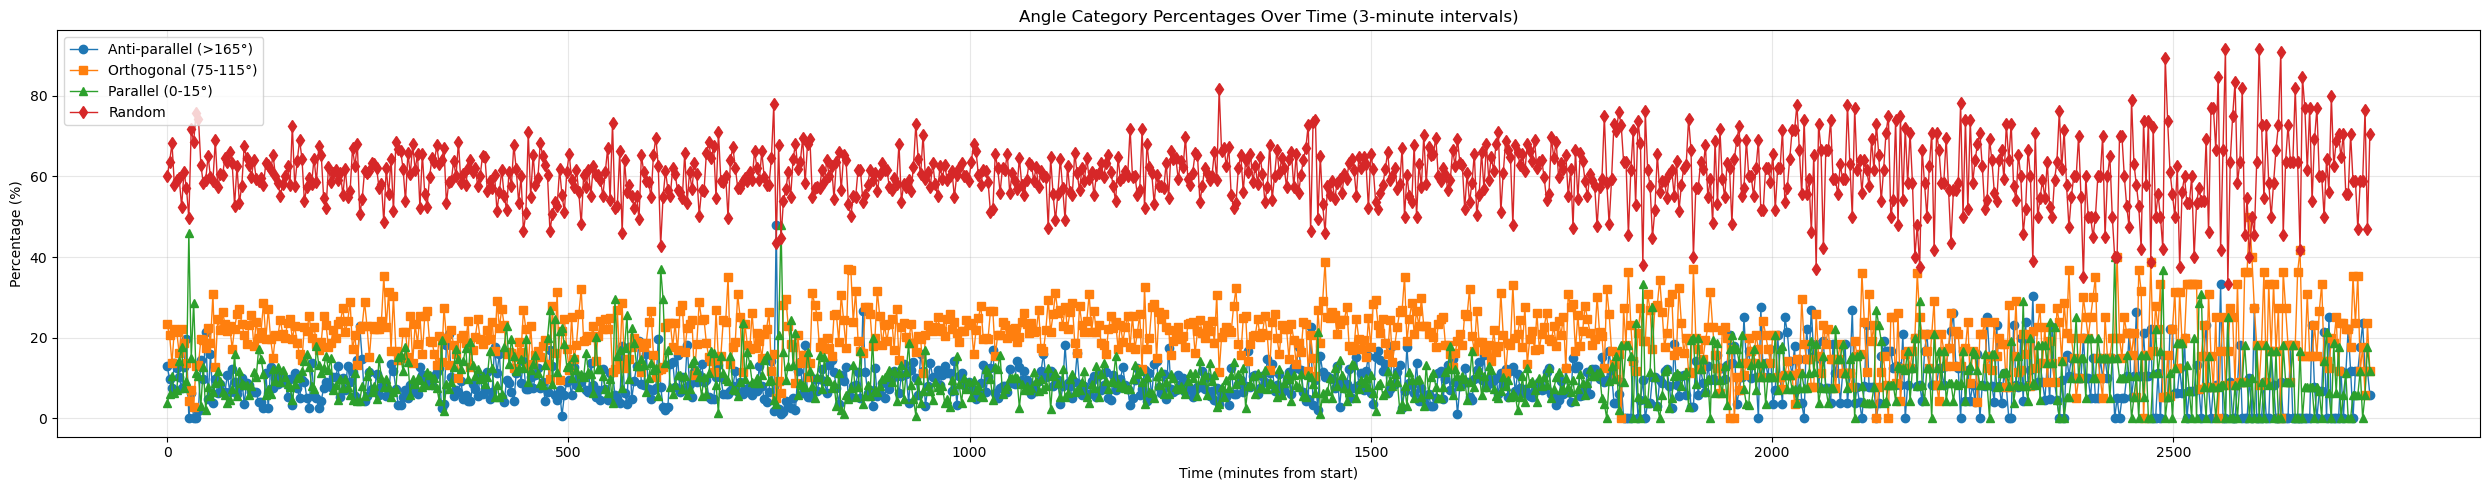

In [51]:
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
#path and data declaration
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS9_Angle = 'Time and theta_POS9.csv'
data = pd.read_csv(PATH + FILENAME_POS9_Angle, sep=',')
#normalize start time to 0
Time = data['Time(min)'] - data['Time(min)'].min() 
Angle = data['Theta(Degrees)']
data['Time_normalized'] = Time
bin_size = 3  # Changed to 3 minutes
max_time = Time.max()
time_bins = np.arange(0, max_time + bin_size, bin_size) 
time_centers = []
anti_para_pcts = []
ortho_pcts = []
para_pcts = []
rando_pcts = []
for i in range(len(time_bins) - 1):
    bin_mask = (Time >= time_bins[i]) & (Time < time_bins[i + 1])
    bin_data = data[bin_mask]
    
    if len(bin_data) > 0:  
        anti_parallel_count = len(bin_data[bin_data['Theta(Degrees)'] > 165])
        orthogonal_count = len(bin_data[(bin_data['Theta(Degrees)'] > 75) & (bin_data['Theta(Degrees)'] < 115)])
        parallel_count = len(bin_data[(bin_data['Theta(Degrees)'] > 0) & (bin_data['Theta(Degrees)'] < 15)])
        rando_count = len(bin_data) - anti_parallel_count - orthogonal_count - parallel_count
        total_count = len(bin_data)
        time_centers.append(time_bins[i]) 
        anti_para_pcts.append((anti_parallel_count / total_count) * 100)
        ortho_pcts.append((orthogonal_count / total_count) * 100)
        para_pcts.append((parallel_count / total_count) * 100)
        rando_pcts.append((rando_count / total_count) * 100)

print("Time-based percentages (3-minute intervals starting from 0):")
for i, time_start in enumerate(time_centers):
    print(f"Time {time_start:.1f} min: Anti-parallel: {anti_para_pcts[i]:.1f}%, "
          f"Orthogonal: {ortho_pcts[i]:.1f}%, Parallel: {para_pcts[i]:.1f}%, Random: {rando_pcts[i]:.1f}%")

plt.figure(figsize=(12, 8))
plt.stackplot(time_centers, anti_para_pcts, ortho_pcts, para_pcts, rando_pcts,
              labels=['Anti-parallel (>165°)', 'Orthogonal (75-115°)', 'Parallel (0-15°)', 'Random'],
              alpha=0.7)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Angle Categories Over Time (3-minute intervals)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(25, 5))
plt.plot(time_centers, anti_para_pcts, 'o-', label='Anti-parallel (>165°)', linewidth=1)
plt.plot(time_centers, ortho_pcts, 's-', label='Orthogonal (75-115°)', linewidth=1)
plt.plot(time_centers, para_pcts, '^-', label='Parallel (0-15°)', linewidth=1)
plt.plot(time_centers, rando_pcts, 'd-', label='Random', linewidth=1)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Angle Category Percentages Over Time (3-minute intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Time-based percentages (3-minute intervals starting from 0):
Time 0.0 min: Anti-parallel: 4.8%, Orthogonal: 23.5%, Parallel: 6.0%, Random: 65.7%
Time 3.0 min: Anti-parallel: 6.5%, Orthogonal: 30.4%, Parallel: 3.6%, Random: 59.5%
Time 6.0 min: Anti-parallel: 3.0%, Orthogonal: 28.6%, Parallel: 4.2%, Random: 64.3%
Time 9.0 min: Anti-parallel: 10.1%, Orthogonal: 17.6%, Parallel: 8.2%, Random: 64.2%
Time 12.0 min: Anti-parallel: 9.2%, Orthogonal: 27.5%, Parallel: 3.3%, Random: 60.1%
Time 15.0 min: Anti-parallel: 13.1%, Orthogonal: 26.2%, Parallel: 9.7%, Random: 51.0%
Time 18.0 min: Anti-parallel: 6.5%, Orthogonal: 12.3%, Parallel: 13.0%, Random: 68.1%
Time 21.0 min: Anti-parallel: 11.1%, Orthogonal: 14.1%, Parallel: 8.1%, Random: 66.7%
Time 24.0 min: Anti-parallel: 6.2%, Orthogonal: 26.9%, Parallel: 5.4%, Random: 61.5%
Time 27.0 min: Anti-parallel: 10.3%, Orthogonal: 13.8%, Parallel: 19.8%, Random: 56.0%
Time 30.0 min: Anti-parallel: 20.9%, Orthogonal: 10.0%, Parallel: 5.5%, Random: 63.6%
T

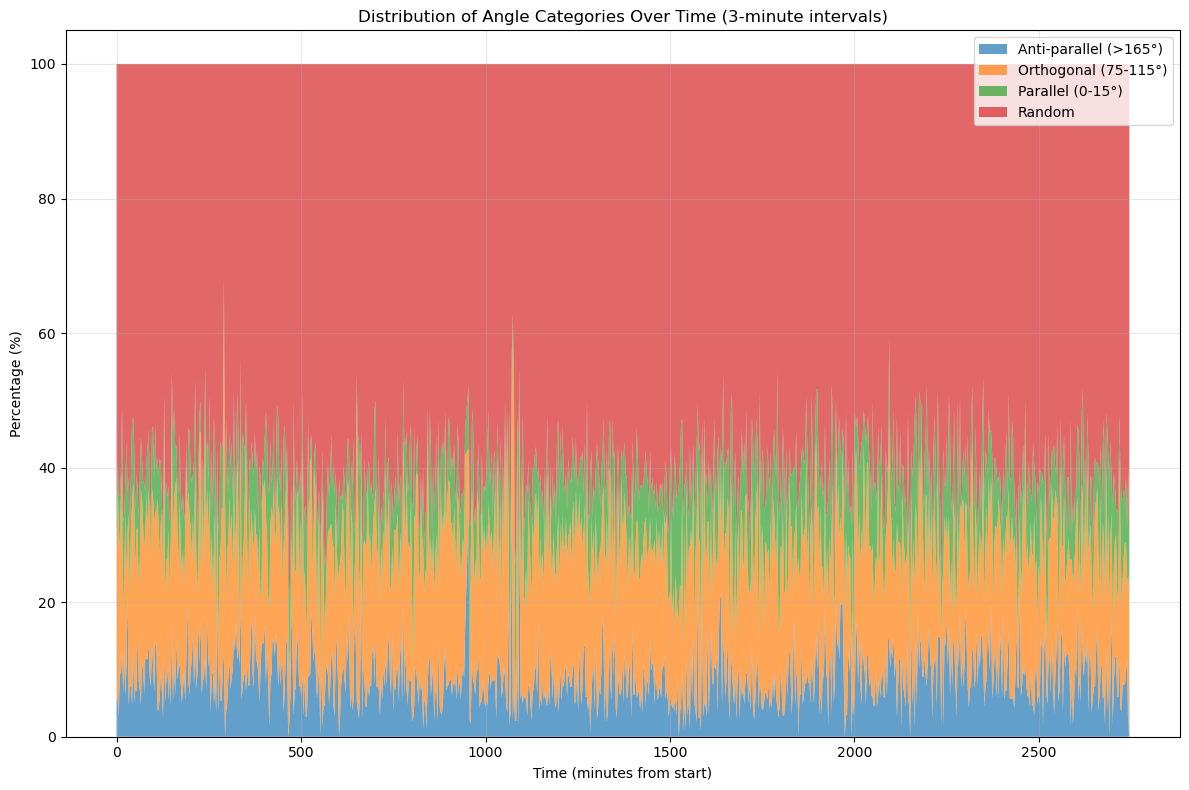

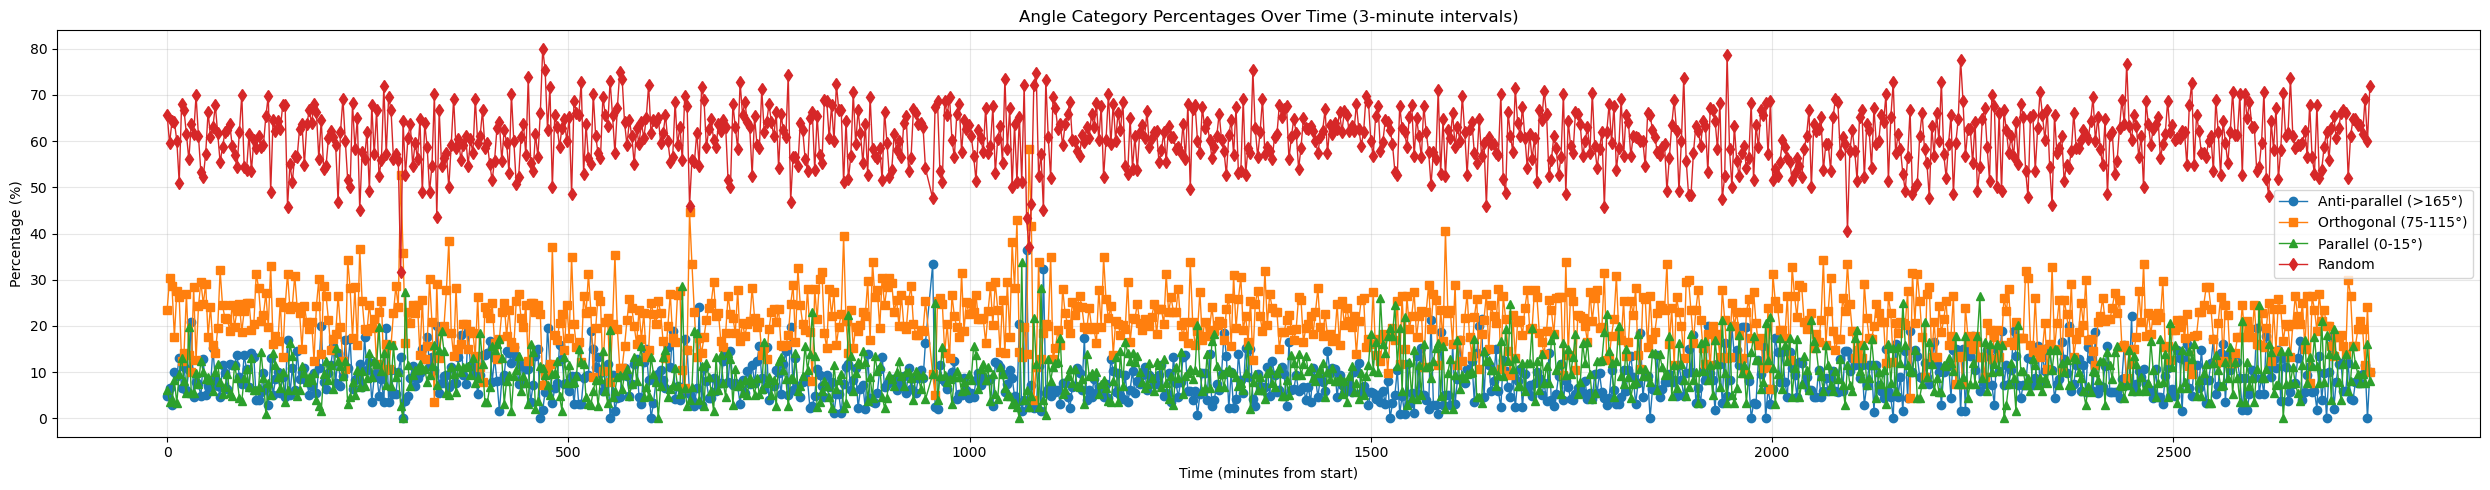

In [2]:
#POS 10
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
#path and data declaration
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS10_Angle = 'Time and theta_POS10.csv'
data = pd.read_csv(PATH + FILENAME_POS10_Angle, sep=',')
#normalize start time to 0
Time = data['Time(min)'] - data['Time(min)'].min() 
Angle = data['Theta(Degrees)']
data['Time_normalized'] = Time
bin_size = 3  # Changed to 3 minutes
max_time = Time.max()
time_bins = np.arange(0, max_time + bin_size, bin_size) 
time_centers = []
anti_para_pcts = []
ortho_pcts = []
para_pcts = []
rando_pcts = []
for i in range(len(time_bins) - 1):
    bin_mask = (Time >= time_bins[i]) & (Time < time_bins[i + 1])
    bin_data = data[bin_mask]
    
    if len(bin_data) > 0:  
        anti_parallel_count = len(bin_data[bin_data['Theta(Degrees)'] > 165])
        orthogonal_count = len(bin_data[(bin_data['Theta(Degrees)'] > 75) & (bin_data['Theta(Degrees)'] < 115)])
        parallel_count = len(bin_data[(bin_data['Theta(Degrees)'] > 0) & (bin_data['Theta(Degrees)'] < 15)])
        rando_count = len(bin_data) - anti_parallel_count - orthogonal_count - parallel_count
        total_count = len(bin_data)
        time_centers.append(time_bins[i]) 
        anti_para_pcts.append((anti_parallel_count / total_count) * 100)
        ortho_pcts.append((orthogonal_count / total_count) * 100)
        para_pcts.append((parallel_count / total_count) * 100)
        rando_pcts.append((rando_count / total_count) * 100)

print("Time-based percentages (3-minute intervals starting from 0):")
for i, time_start in enumerate(time_centers):
    print(f"Time {time_start:.1f} min: Anti-parallel: {anti_para_pcts[i]:.1f}%, "
          f"Orthogonal: {ortho_pcts[i]:.1f}%, Parallel: {para_pcts[i]:.1f}%, Random: {rando_pcts[i]:.1f}%")

plt.figure(figsize=(12, 8))
plt.stackplot(time_centers, anti_para_pcts, ortho_pcts, para_pcts, rando_pcts,
              labels=['Anti-parallel (>165°)', 'Orthogonal (75-115°)', 'Parallel (0-15°)', 'Random'],
              alpha=0.7)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Angle Categories Over Time (3-minute intervals)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(25, 5))
plt.plot(time_centers, anti_para_pcts, 'o-', label='Anti-parallel (>165°)', linewidth=1)
plt.plot(time_centers, ortho_pcts, 's-', label='Orthogonal (75-115°)', linewidth=1)
plt.plot(time_centers, para_pcts, '^-', label='Parallel (0-15°)', linewidth=1)
plt.plot(time_centers, rando_pcts, 'd-', label='Random', linewidth=1)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Angle Category Percentages Over Time (3-minute intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Time-based percentages (3-minute intervals starting from 0):
Time 0.0 min: Anti-parallel: 7.1%, Orthogonal: 22.5%, Parallel: 6.6%, Random: 63.7%
Time 3.0 min: Anti-parallel: 3.8%, Orthogonal: 15.4%, Parallel: 10.4%, Random: 70.3%
Time 6.0 min: Anti-parallel: 10.4%, Orthogonal: 22.0%, Parallel: 6.6%, Random: 61.0%
Time 9.0 min: Anti-parallel: 8.8%, Orthogonal: 29.8%, Parallel: 9.4%, Random: 51.9%
Time 12.0 min: Anti-parallel: 15.6%, Orthogonal: 19.6%, Parallel: 6.1%, Random: 58.7%
Time 15.0 min: Anti-parallel: 11.6%, Orthogonal: 17.1%, Parallel: 9.9%, Random: 61.3%
Time 18.0 min: Anti-parallel: 7.8%, Orthogonal: 17.8%, Parallel: 10.6%, Random: 63.9%
Time 21.0 min: Anti-parallel: 9.0%, Orthogonal: 23.6%, Parallel: 6.2%, Random: 61.2%
Time 24.0 min: Anti-parallel: 13.1%, Orthogonal: 21.0%, Parallel: 5.1%, Random: 60.8%
Time 27.0 min: Anti-parallel: 10.2%, Orthogonal: 16.5%, Parallel: 7.4%, Random: 65.9%
Time 30.0 min: Anti-parallel: 12.5%, Orthogonal: 19.9%, Parallel: 7.4%, Random: 60.2%


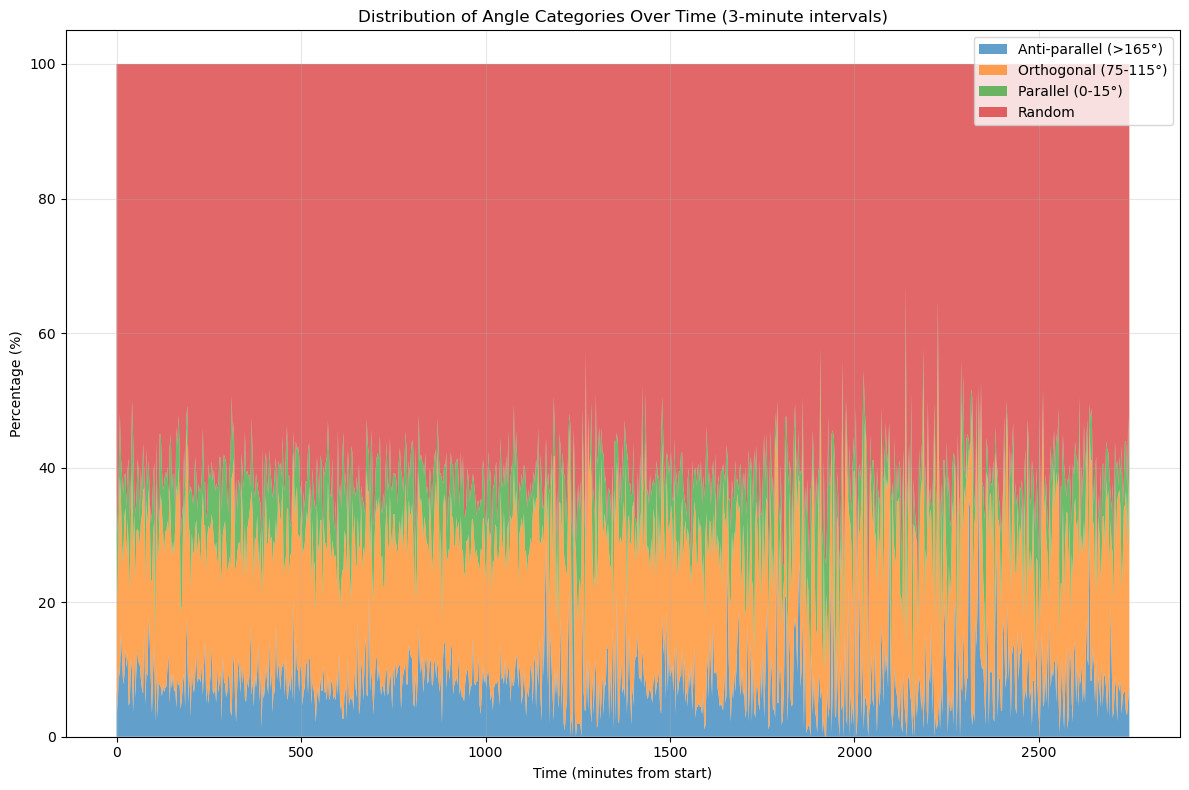

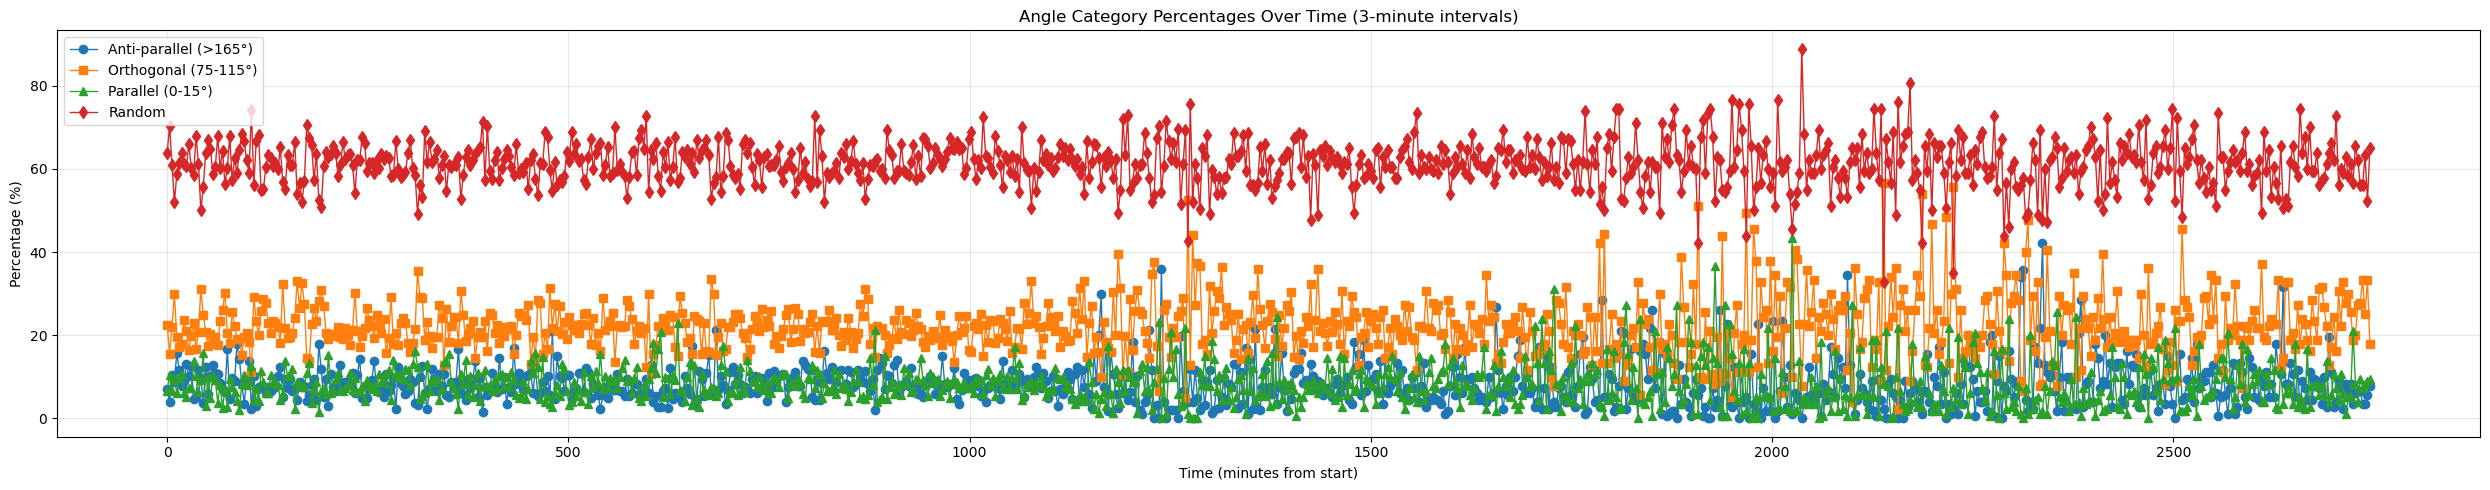

In [5]:
#POS 11
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
#path and data declaration
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS11_Angle = 'Time and theta_POS11.csv'
data = pd.read_csv(PATH + FILENAME_POS11_Angle, sep=',')
#normalize start time to 0
Time = data['Time(min)'] - data['Time(min)'].min() 
Angle = data['Theta(Degrees)']
data['Time_normalized'] = Time
bin_size = 3  # Changed to 3 minutes
max_time = Time.max()
time_bins = np.arange(0, max_time + bin_size, bin_size) 
time_centers = []
anti_para_pcts = []
ortho_pcts = []
para_pcts = []
rando_pcts = []
for i in range(len(time_bins) - 1):
    bin_mask = (Time >= time_bins[i]) & (Time < time_bins[i + 1])
    bin_data = data[bin_mask]
    
    if len(bin_data) > 0:  
        anti_parallel_count = len(bin_data[bin_data['Theta(Degrees)'] > 165])
        orthogonal_count = len(bin_data[(bin_data['Theta(Degrees)'] > 75) & (bin_data['Theta(Degrees)'] < 115)])
        parallel_count = len(bin_data[(bin_data['Theta(Degrees)'] > 0) & (bin_data['Theta(Degrees)'] < 15)])
        rando_count = len(bin_data) - anti_parallel_count - orthogonal_count - parallel_count
        total_count = len(bin_data)
        time_centers.append(time_bins[i]) 
        anti_para_pcts.append((anti_parallel_count / total_count) * 100)
        ortho_pcts.append((orthogonal_count / total_count) * 100)
        para_pcts.append((parallel_count / total_count) * 100)
        rando_pcts.append((rando_count / total_count) * 100)

print("Time-based percentages (3-minute intervals starting from 0):")
for i, time_start in enumerate(time_centers):
    print(f"Time {time_start:.1f} min: Anti-parallel: {anti_para_pcts[i]:.1f}%, "
          f"Orthogonal: {ortho_pcts[i]:.1f}%, Parallel: {para_pcts[i]:.1f}%, Random: {rando_pcts[i]:.1f}%")

plt.figure(figsize=(12, 8))
plt.stackplot(time_centers, anti_para_pcts, ortho_pcts, para_pcts, rando_pcts,
              labels=['Anti-parallel (>165°)', 'Orthogonal (75-115°)', 'Parallel (0-15°)', 'Random'],
              alpha=0.7)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Angle Categories Over Time (3-minute intervals)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(25, 5))
plt.plot(time_centers, anti_para_pcts, 'o-', label='Anti-parallel (>165°)', linewidth=1)
plt.plot(time_centers, ortho_pcts, 's-', label='Orthogonal (75-115°)', linewidth=1)
plt.plot(time_centers, para_pcts, '^-', label='Parallel (0-15°)', linewidth=1)
plt.plot(time_centers, rando_pcts, 'd-', label='Random', linewidth=1)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Angle Category Percentages Over Time (3-minute intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Time-based percentages (3-minute intervals starting from 0):
Time 0.0 min: Anti-parallel: 15.2%, Orthogonal: 23.4%, Parallel: 3.4%, Random: 57.9%
Time 3.0 min: Anti-parallel: 6.1%, Orthogonal: 27.9%, Parallel: 4.8%, Random: 61.2%
Time 6.0 min: Anti-parallel: 12.9%, Orthogonal: 25.2%, Parallel: 5.4%, Random: 56.5%
Time 9.0 min: Anti-parallel: 7.5%, Orthogonal: 22.6%, Parallel: 9.6%, Random: 60.3%
Time 12.0 min: Anti-parallel: 8.2%, Orthogonal: 22.6%, Parallel: 8.2%, Random: 61.0%
Time 15.0 min: Anti-parallel: 4.1%, Orthogonal: 23.3%, Parallel: 8.9%, Random: 63.7%
Time 18.0 min: Anti-parallel: 9.0%, Orthogonal: 19.4%, Parallel: 12.5%, Random: 59.0%
Time 21.0 min: Anti-parallel: 9.0%, Orthogonal: 19.4%, Parallel: 10.4%, Random: 61.1%
Time 24.0 min: Anti-parallel: 8.3%, Orthogonal: 22.9%, Parallel: 5.6%, Random: 63.2%
Time 27.0 min: Anti-parallel: 4.1%, Orthogonal: 20.7%, Parallel: 13.8%, Random: 61.4%
Time 30.0 min: Anti-parallel: 10.5%, Orthogonal: 15.4%, Parallel: 13.3%, Random: 60.8%
T

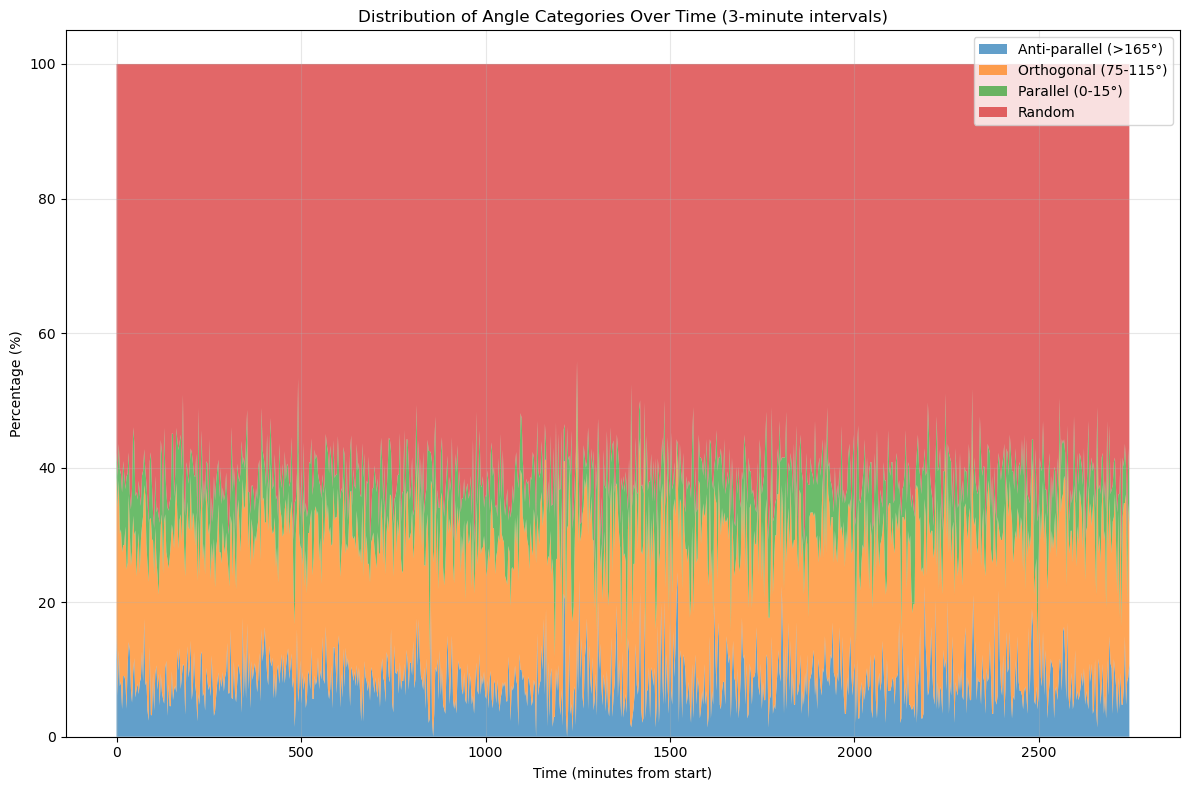

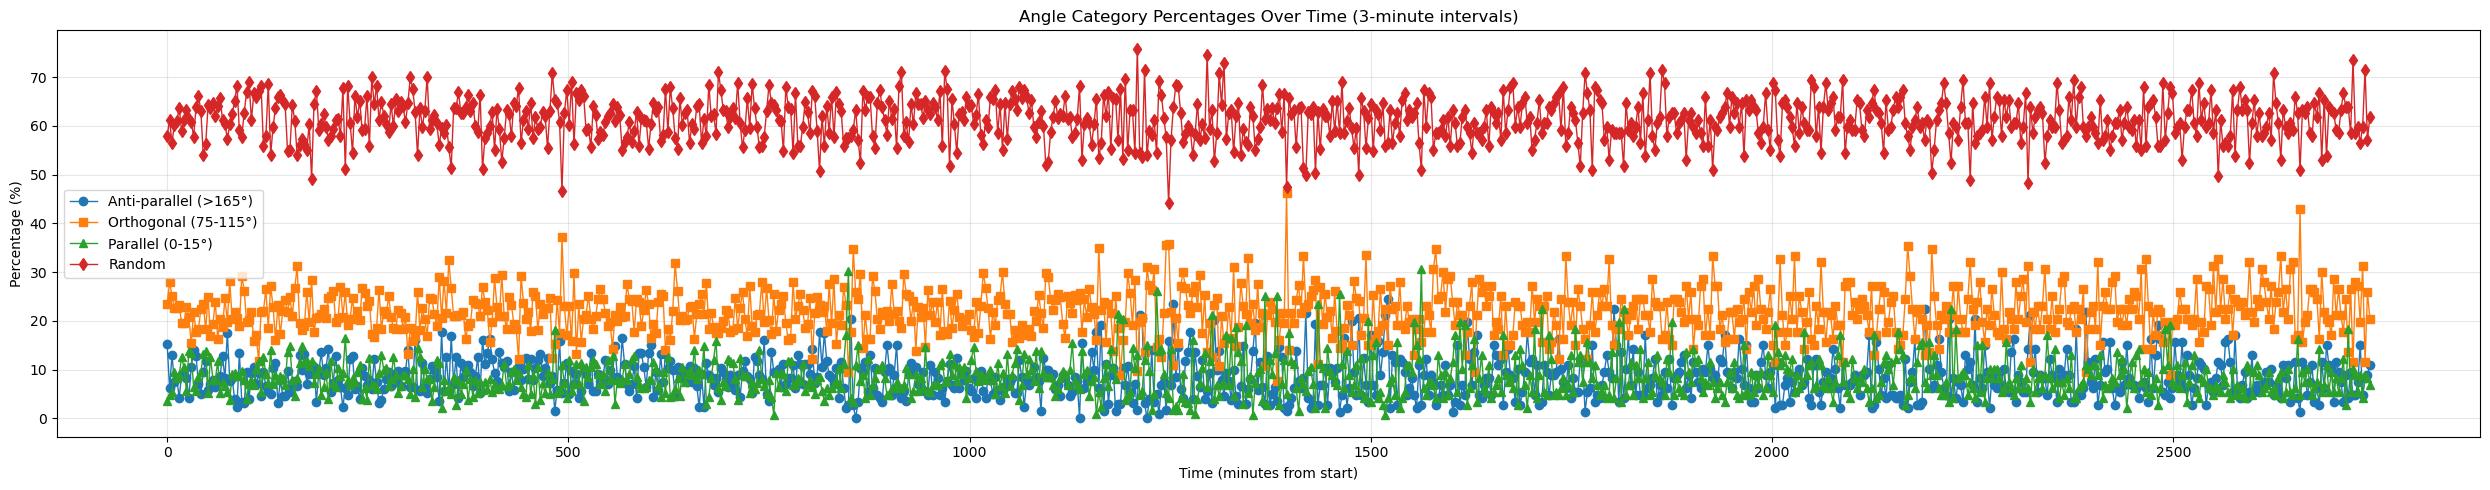

In [6]:
#POS 12
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
#path and data declaration
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS12_Angle = 'Time and theta_POS12.csv'
data = pd.read_csv(PATH + FILENAME_POS12_Angle, sep=',')
#normalize start time to 0
Time = data['Time(min)'] - data['Time(min)'].min() 
Angle = data['Theta(Degrees)']
data['Time_normalized'] = Time
bin_size = 3  # Changed to 3 minutes
max_time = Time.max()
time_bins = np.arange(0, max_time + bin_size, bin_size) 
time_centers = []
anti_para_pcts = []
ortho_pcts = []
para_pcts = []
rando_pcts = []
for i in range(len(time_bins) - 1):
    bin_mask = (Time >= time_bins[i]) & (Time < time_bins[i + 1])
    bin_data = data[bin_mask]
    
    if len(bin_data) > 0:  
        anti_parallel_count = len(bin_data[bin_data['Theta(Degrees)'] > 165])
        orthogonal_count = len(bin_data[(bin_data['Theta(Degrees)'] > 75) & (bin_data['Theta(Degrees)'] < 115)])
        parallel_count = len(bin_data[(bin_data['Theta(Degrees)'] > 0) & (bin_data['Theta(Degrees)'] < 15)])
        rando_count = len(bin_data) - anti_parallel_count - orthogonal_count - parallel_count
        total_count = len(bin_data)
        time_centers.append(time_bins[i]) 
        anti_para_pcts.append((anti_parallel_count / total_count) * 100)
        ortho_pcts.append((orthogonal_count / total_count) * 100)
        para_pcts.append((parallel_count / total_count) * 100)
        rando_pcts.append((rando_count / total_count) * 100)

print("Time-based percentages (3-minute intervals starting from 0):")
for i, time_start in enumerate(time_centers):
    print(f"Time {time_start:.1f} min: Anti-parallel: {anti_para_pcts[i]:.1f}%, "
          f"Orthogonal: {ortho_pcts[i]:.1f}%, Parallel: {para_pcts[i]:.1f}%, Random: {rando_pcts[i]:.1f}%")

plt.figure(figsize=(12, 8))
plt.stackplot(time_centers, anti_para_pcts, ortho_pcts, para_pcts, rando_pcts,
              labels=['Anti-parallel (>165°)', 'Orthogonal (75-115°)', 'Parallel (0-15°)', 'Random'],
              alpha=0.7)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Angle Categories Over Time (3-minute intervals)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(25, 5))
plt.plot(time_centers, anti_para_pcts, 'o-', label='Anti-parallel (>165°)', linewidth=1)
plt.plot(time_centers, ortho_pcts, 's-', label='Orthogonal (75-115°)', linewidth=1)
plt.plot(time_centers, para_pcts, '^-', label='Parallel (0-15°)', linewidth=1)
plt.plot(time_centers, rando_pcts, 'd-', label='Random', linewidth=1)
plt.xlabel('Time (minutes from start)')
plt.ylabel('Percentage (%)')
plt.title('Angle Category Percentages Over Time (3-minute intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()